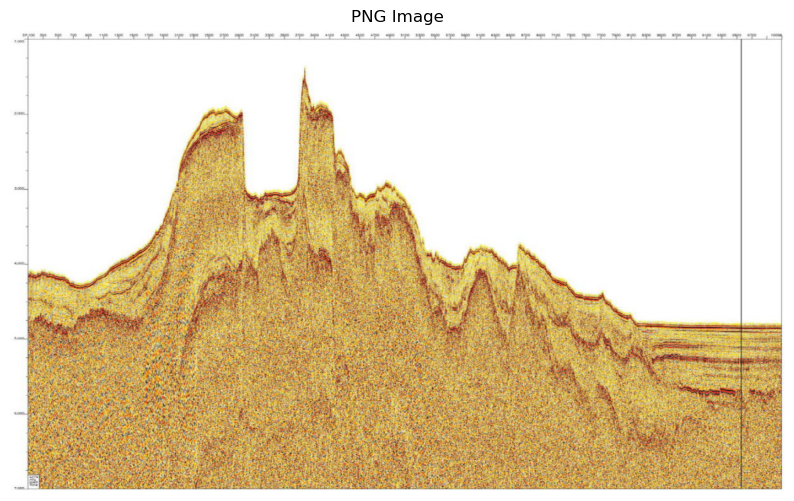

Image shape: (943, 1585, 4)
Image data type: uint8
Minimum value in data: 0
Maximum value in data: 255
Mean value in data: 212.51536458246218
SEGY file saved to C:\Users\lmag0269\OneDrive - The University of Sydney (Staff)\Coral_Sea_seismic\Exon_2006_Mellish\GA_274_03.sgy


In [3]:
import numpy as np
from PIL import Image, ImageFile
import matplotlib.pyplot as plt
import os
from obspy import Stream, Trace
from obspy.io.segy.segy import SEGYBinaryFileHeader, SEGYTraceHeader

# Increase the limit for max image pixels - ADDED FOR BIG LINES
Image.MAX_IMAGE_PIXELS = None
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Load the PNG image
# Update the path to your PNG file here
image_path = r'C:\Users\lmag0269\OneDrive - The University of Sydney (Staff)\Coral_Sea_seismic\Exon_2006_Mellish\GA_274_03.png'

if not os.path.exists(image_path):
    print("File not found. Please check the file path.")
else:
    image = Image.open(image_path)
    data = np.array(image)

    # Convert RGBA to Grayscale if necessary
    if data.ndim == 3 and data.shape[2] == 4:
        grayscale_data = np.dot(data[..., :3], [0.2989, 0.5870, 0.1140]).astype(np.float32)
    elif data.ndim == 3 and data.shape[2] == 3:
        grayscale_data = np.dot(data, [0.2989, 0.5870, 0.1140]).astype(np.float32)
    else:
        grayscale_data = data

    # Reshape grayscale_data into a 2D array
    seismic_traces = grayscale_data  # Keep as is

    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.title('PNG Image')
    plt.axis('off')
    plt.show()

    # Print basic information about the image data
    print(f"Image shape: {data.shape}")
    print(f"Image data type: {data.dtype}")
    print(f"Minimum value in data: {np.min(data)}")
    print(f"Maximum value in data: {np.max(data)}")
    print(f"Mean value in data: {np.mean(data)}")

    # Initialize SEGY binary header
    binary_header = SEGYBinaryFileHeader()
    binary_header.sample_interval = 1000  # 1 millisecond, as an example
    binary_header.num_samples = seismic_traces.shape[0]  # Number of samples per trace
    binary_header.data_sample_format = 1  # IBM float

    # Create a stream to hold the traces
    stream = Stream()

    # Loop through each trace to create SEGYTrace
    for i in range(seismic_traces.shape[1]):  # Loop over number of traces
        trace_data = seismic_traces[:, i]  # Get the ith trace
        trace = Trace()
        
        # Set trace data and headers
        trace.data = trace_data.astype(np.float32)
        trace.stats.network = "SEISMIC"
        trace.stats.station = f"Trace_{i + 1}"
        trace.stats.sampling_rate = 1000  # Sampling rate in Hz (1 / 0.001 seconds)
        trace.stats.delta = 0.001  # Sample interval in seconds
        
        # Initialize and set the segy attribute and trace header
        trace.stats.segy = {}
        trace.stats.segy.trace_header = SEGYTraceHeader()
        trace.stats.segy.trace_header.trace_sequence_number_within_line = i + 1
        trace.stats.segy.trace_header.number_of_samples_in_this_trace = len(trace_data)
        trace.stats.segy.trace_header.sample_interval_in_ms_for_this_trace = int(trace.stats.delta * 1e6)  # in microseconds

        # Add trace and header to the stream
        stream.append(trace)

     #Write to SEGY file
     #Update the output path to your desired location
    output_segy_path = r'C:\Users\lmag0269\OneDrive - The University of Sydney (Staff)\Coral_Sea_seismic\Exon_2006_Mellish\GA_274_03.sgy'
    stream.write(output_segy_path, format='SEGY', data_encoding=1)  # data_encoding=1 for IBM float

    print(f"SEGY file saved to {output_segy_path}")
